In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# Load
df = pd.read_csv("../data/raw/Food delivery.csv")

# Drop unused columns
df = df.drop(columns=[
    "Delivery_person_ID",
    "Delivery_person_Age",
    "Order_Date",
    "Time_Orderd",
    "Type_of_order",
    "Festival",
])

# Clean text and convert types
df = df.replace("NaN ", pd.NA)

df["ID"] = df["ID"].str.strip()
df["Delivery_person_Ratings"] = pd.to_numeric(df["Delivery_person_Ratings"], errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], format="%H:%M:%S", errors="coerce").dt.time
df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "", regex=False)
df["Weatherconditions"] = df["Weatherconditions"].replace("NaN", pd.NA, regex=False).str.strip()
df["Road_traffic_density"] = df["Road_traffic_density"].str.strip()
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors="coerce")
df["City"] = df["City"].str.strip()
df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min) ", "", regex=False)
df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors="coerce")
df["Type_of_vehicle"] = df["Type_of_vehicle"].str.strip()
df["Vehicle_condition"] = pd.to_numeric(df["Vehicle_condition"], errors="coerce")

# Missing values: median for numeric, mode for categorical
df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(df["Delivery_person_Ratings"].median())
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].median())
df["Weatherconditions"] = df["Weatherconditions"].fillna(df["Weatherconditions"].mode()[0])
df["Road_traffic_density"] = df["Road_traffic_density"].fillna(df["Road_traffic_density"].mode()[0])
df["City"] = df["City"].fillna(df["City"].mode()[0])
df["Type_of_vehicle"] = df["Type_of_vehicle"].fillna(df["Type_of_vehicle"].mode()[0])
df["Vehicle_condition"] = df["Vehicle_condition"].fillna(df["Vehicle_condition"].mode()[0])

# Fix negative coordinates
coord_cols = ["Restaurant_latitude", "Restaurant_longitude",
              "Delivery_location_latitude", "Delivery_location_longitude"]
df[coord_cols] = df[coord_cols].abs()

df = df[(df[["Restaurant_latitude", "Delivery_location_latitude"]] > 5).all(axis=1)
        & (df[["Restaurant_longitude", "Delivery_location_longitude"]] > 60).all(axis=1)
        & (df["Delivery_person_Ratings"] <= 5)].copy()

df = df.drop_duplicates()

# Feature engineering: distance_km (haversine)
lat1 = np.radians(df["Restaurant_latitude"])
lon1 = np.radians(df["Restaurant_longitude"])
lat2 = np.radians(df["Delivery_location_latitude"])
lon2 = np.radians(df["Delivery_location_longitude"])

a = np.sin((lat2 - lat1) / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2)**2
df["distance_km"] = 6371 * 2 * np.arcsin(np.sqrt(a))

# Feature engineering: is_peak_hour
hour = pd.to_datetime(df["Time_Order_picked"].astype(str), format="%H:%M:%S").dt.hour
df["is_peak_hour"] = hour.isin([12, 13, 14, 19, 20, 21, 22]).astype(int)

Path("../data/clean").mkdir(parents=True, exist_ok=True)
df.to_csv("../data/clean/food_delivery_clean.csv", index=False)

Vehicle_condition
1    13851
0    13815
2    13806
3      435
Name: count, dtype: int64

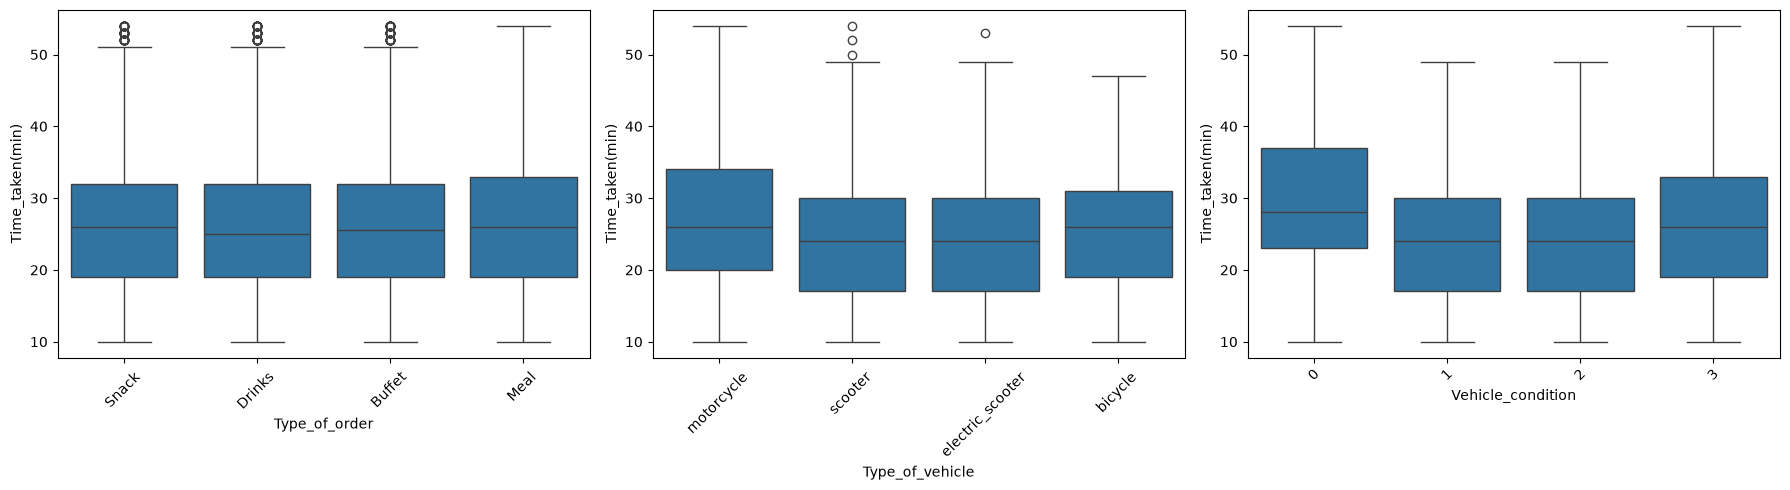

       Delivery_person_Ratings  Restaurant_latitude  Restaurant_longitude  \
count             41907.000000         41907.000000          41907.000000   
mean                  4.633729            18.911520             76.921826   
std                   0.325749             5.467251              3.502642   
min                   1.000000             9.957144             72.768726   
25%                   4.500000            12.986047             73.897902   
50%                   4.700000            19.065838             76.618203   
75%                   4.800000            22.751234             78.368855   
max                   5.000000            30.914057             88.433452   

       Delivery_location_latitude  Delivery_location_longitude  \
count                41907.000000                 41907.000000   
mean                    18.975184                    76.985489   
std                      5.469030                     3.502799   
min                      9.967144         

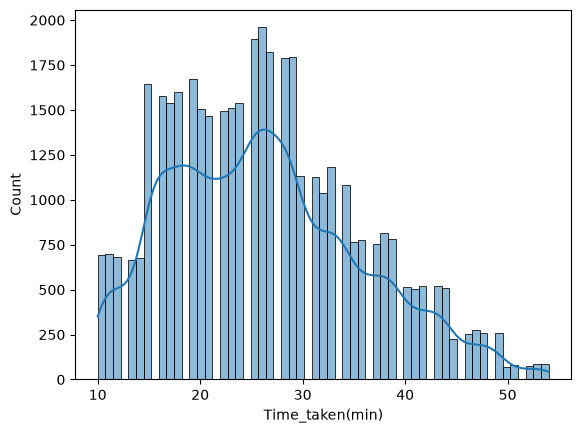

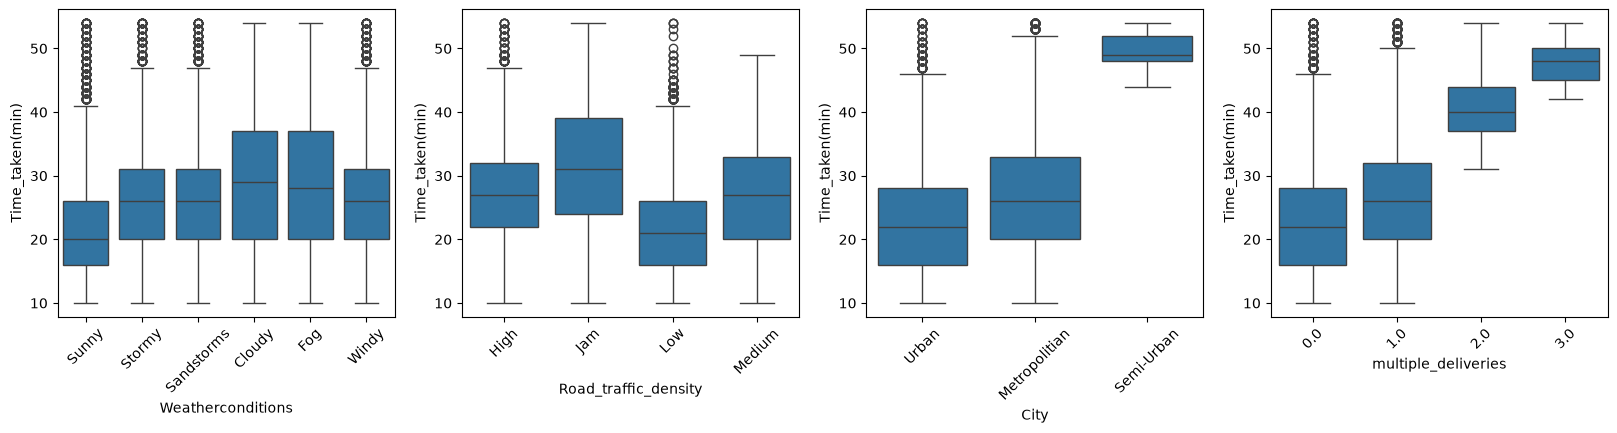

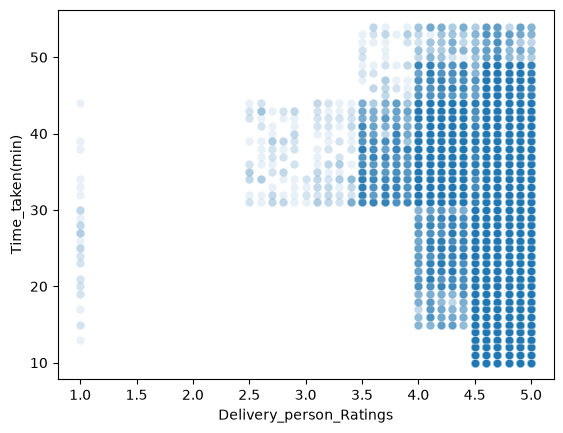

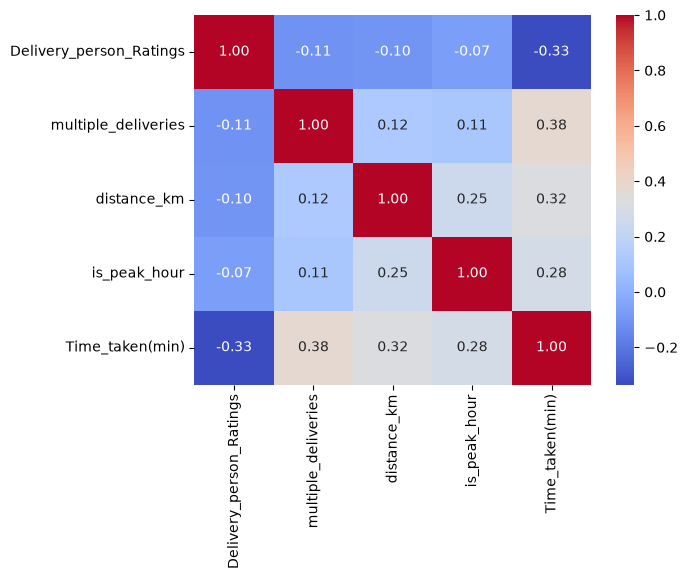

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df = pd.read_csv("../data/clean/food_delivery_clean.csv")

# descriptive stats
print(df.describe())
for c in ["Weatherconditions", "Road_traffic_density", "City", "multiple_deliveries"]:
    print(df[c].value_counts(), "\n")

# Delivery time averages 26.3 min (median 26, std 9.4). Ratings average 4.63 and distance averages 9.72 km.
# The most frequent category is Fog for weather (the six conditions are nearly balanced, 6.7k to 7.5k each),
# Low for traffic (14,709 rows) and Metropolitian for city (32,492 rows, about 78%). Semi-Urban has only 149 rows.
# Most deliveries carry 1 simultaneous delivery (26,807).
# target distribution
sns.histplot(df["Time_taken(min)"], kde=True)
plt.show()
# Delivery time ranges from 10 to 54 min. Half of the deliveries fall between 19 and 32 min (Q1 to Q3),
# and the mean (26.3) is close to the median (26), so the distribution is roughly symmetric,
# with a slightly longer tail on the right (long deliveries).

# target vs categorical variables
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, c in zip(axes, ["Weatherconditions", "Road_traffic_density", "City", "multiple_deliveries"]):
    sns.boxplot(x=df[c], y=df["Time_taken(min)"], ax=ax)
    ax.tick_params(axis="x", rotation=45)
plt.show()
# Traffic: Jam has the highest median (~31 min) and Low the lowest (~21 min), a gap of about 10 min.
# Weather: Cloudy (~29) and Fog (~28) are the slowest, Sunny is the fastest (~20).
# City: Semi-Urban is the slowest (~49 min) but has only 149 rows, so it is less reliable. Urban is the fastest (~22).
# Multiple deliveries: time rises steadily from ~22 min (0) to ~48 min (3), the clearest pattern of the four.

# target vs Delivery_person_Ratings
sns.scatterplot(x=df["Delivery_person_Ratings"], y=df["Time_taken(min)"], alpha=0.1)
plt.show()
# Most ratings fall between 4.5 and 4.8. Lower-rated drivers tend to have longer delivery times
# (r = -0.33), a moderate negative relationship.

# correlation matrix
num = ["Delivery_person_Ratings", "multiple_deliveries", "distance_km", "is_peak_hour", "Time_taken(min)"]
sns.heatmap(df[num].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()
# The variables most correlated with Time_taken are multiple_deliveries (r = 0.38),
# Delivery_person_Ratings (r = -0.33) and distance_km (r = 0.32), followed by is_peak_hour (r = 0.28).
# All four have a moderate linear relationship with delivery time, and none is close to 0.
# The explanatory variables are weakly correlated with each other (highest: distance_km and
# is_peak_hour, r = 0.25), so multicollinearity is not a concern.
# Pearson only measures linear relationships and no single variable exceeds r = 0.4, so combining
# them (and the categoricals: traffic, weather, city) is needed to predict well.


### Conclusion
# The variables most tied to delivery time are the number of simultaneous deliveries, the driver rating and the distance,
# followed by peak hour. Among the categoricals, city type (Semi-Urban), traffic (Jam vs Low) and weather (Cloudy/Fog vs Sunny)
# also shift the median clearly. These will be the main drivers in the model.

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/clean/food_delivery_clean.csv")

X = df.drop(columns=["ID", "Time_Order_picked", "Restaurant_latitude", "Restaurant_longitude",
                     "Delivery_location_latitude", "Delivery_location_longitude", "Time_taken(min)"])
y = df["Time_taken(min)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cat_cols = ["Weatherconditions", "Road_traffic_density", "City", "Type_of_vehicle"]
num_cols = ["Delivery_person_Ratings", "multiple_deliveries", "distance_km", "is_peak_hour", "Vehicle_condition"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
])

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

results = []
for name, model in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, pred),
    })

pd.DataFrame(results).sort_values("RMSE").round(3)

,Model,MAE,MSE,RMSE,R2
2,Random Forest,4.136,28.759,5.363,0.673
3,Gradient Boosting,4.254,28.863,5.372,0.672
0,Linear Regression,5.272,43.756,6.615,0.502
1,Decision Tree,5.349,50.446,7.103,0.426


In [26]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

pipe = Pipeline([
    ("prep", preprocess),
    ("model", GradientBoostingRegressor(random_state=42)),
])

param_dist = {
    "model__n_estimators": [100, 200, 300, 400, 500, 1000],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5, 6, 7],
    "model__min_samples_leaf": [1, 5, 10, 20],
    "model__subsample": [0.7, 0.85, 1.0],
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
best_pipe = search.best_estimator_

Best params: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__min_samples_leaf': 20, 'model__max_depth': 7, 'model__learning_rate': 0.1}


In [28]:
pred = best_pipe.predict(X_test)
mse = mean_squared_error(y_test, pred)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

n = len(y_test)
p = best_pipe.named_steps["prep"].transform(X_test).shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE: {mae:.3f}, MSE: {mse:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}, Adjusted R2: {adj_r2:.3f}")

MAE: 3.885, MSE: 24.651, RMSE: 4.965, R2: 0.719, Adjusted R2: 0.719


In [29]:
train_pred = best_pipe.predict(X_train)
print(f"Train R2: {r2_score(y_train, train_pred):.3f}  |  Test R2: {r2:.3f}")

Train R2: 0.744  |  Test R2: 0.719


In [30]:
import joblib
from pathlib import Path

Path("../models").mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, "../models/delivery_time_model.joblib")

['../models/delivery_time_model.joblib']

In [31]:
importances = best_pipe.named_steps["model"].feature_importances_
feature_names = best_pipe.named_steps["prep"].get_feature_names_out()
pd.Series(importances, index=feature_names).sort_values(ascending=False)


num__Delivery_person_Ratings              0.259134
num__multiple_deliveries                  0.164923
cat__Road_traffic_density_Low             0.136073
num__distance_km                          0.120915
num__Vehicle_condition                    0.093098
cat__Weatherconditions_Sunny              0.072109
cat__Weatherconditions_Fog                0.047671
cat__Weatherconditions_Cloudy             0.047474
cat__Road_traffic_density_Medium          0.016916
cat__Road_traffic_density_Jam             0.016530
cat__City_Urban                           0.007267
cat__City_Semi-Urban                      0.004244
cat__City_Metropolitian                   0.002787
cat__Weatherconditions_Windy              0.002420
num__is_peak_hour                         0.002400
cat__Weatherconditions_Stormy             0.002060
cat__Road_traffic_density_High            0.001697
cat__Weatherconditions_Sandstorms         0.001299
cat__Type_of_vehicle_scooter              0.000421
cat__Type_of_vehicle_motorcycle